# Análisis de venta de la tienda de TCGs Rapture

## Objetivo: 
Analizar las ventas de los meses de enero, febrero y marzo por categoría de producto, y determinar si la diferencia entre los ingresos de Pokemón es estadísticamente significativa a los de Magic durante el trimestre con el fin de ajustar el presupuesto de inversión en el mes de abril.

In [42]:
# Cargamos las librerías necesarias:
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
# Cargamos los datos de ventas de los tres meses en un DataFrame de pandas:
ventas_enero = pd.read_excel("C:/Users/Alexis García/Documents/Alo/Proyecto Rapture/ventas ene 2026 (1).xlsx")
ventas_febrero = pd.read_excel("C:/Users/Alexis García/Documents/Alo/Proyecto Rapture/ventas febrero 206 (1).xlsx")  
ventas_marzo = pd.read_excel("C:/Users/Alexis García/Documents/Alo/Proyecto Rapture/ventas marzo 2026 (1).xlsx")

In [44]:
# Mostramos las primeras filas de cada DataFrame para verificar que se han cargado correctamente:
print("Ventas de Enero:")
print(ventas_enero.head())
print("Ventas de Febrero:")
print(ventas_febrero.head())
print("Ventas de Marzo:")
print(ventas_marzo.head())

Ventas de Enero:
          Codigo                                        Descripcion  Cantidad  \
0   722626039829           Coqui BCW Sleeves Standard Iridian White         1   
1  5706569150679  Coqui Dragon Shield Sleeves Standard Dual Matt...         2   
2  5706569150549  Coqui Dragon Shield Sleeves Standard Dual Matt...         5   
3  5706569150310  Coqui Dragon Shield Sleeves Standard Dual Matt...         1   
4  5706569150488  Coqui Dragon Shield Sleeves Standard Dual Matt...         5   

   Precio Usado  Precio Costo Departamento  
0         230.0        155.34        Coqui  
1         260.0        158.41        Coqui  
2         260.0        177.89        Coqui  
3         260.0        177.89        Coqui  
4         260.0        177.89        Coqui  
Ventas de Febrero:
          Codigo                                        Descripcion  Cantidad  \
0   722626039904        Coqui BCW Sleeves Standard Iridian Mulberry         1   
1  5706569110390  Coqui Dragon Shield Sleeves

## Preprocesamiento de datos

In [45]:
# Agregamos una nueva columna 'mes' a cada DataFrame para identificar el mes de cada venta:
ventas_enero['mes'] = 'enero'
ventas_febrero['mes'] = 'febrero'
ventas_marzo['mes'] = 'marzo'

# Unimos los tres DataFrames en uno solo utilizando el método concat() para tener la información de los tres meses en un solo DataFrame:
ventas_trimestre = pd.concat([ventas_enero, ventas_febrero, ventas_marzo], ignore_index=True)
# Llamamos al método print() para mostrar las primeras filas del DataFrame combinado y verificar que se ha unido correctamente:
print("Ventas del trimestre:")
print(ventas_trimestre.head())


Ventas del trimestre:
          Codigo                                        Descripcion  Cantidad  \
0   722626039829           Coqui BCW Sleeves Standard Iridian White         1   
1  5706569150679  Coqui Dragon Shield Sleeves Standard Dual Matt...         2   
2  5706569150549  Coqui Dragon Shield Sleeves Standard Dual Matt...         5   
3  5706569150310  Coqui Dragon Shield Sleeves Standard Dual Matt...         1   
4  5706569150488  Coqui Dragon Shield Sleeves Standard Dual Matt...         5   

   Precio Usado  Precio Costo Departamento    mes  
0         230.0        155.34        Coqui  enero  
1         260.0        158.41        Coqui  enero  
2         260.0        177.89        Coqui  enero  
3         260.0        177.89        Coqui  enero  
4         260.0        177.89        Coqui  enero  


In [46]:
# Utilizamos el método info() para obtener información sobre los tipos de datos y la cantidad de valores no nulos en el data frame:
print("Información de ventas:")
print(ventas_trimestre.info())

Información de ventas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Codigo        164 non-null    int64  
 1   Descripcion   164 non-null    object 
 2   Cantidad      164 non-null    int64  
 3   Precio Usado  164 non-null    float64
 4   Precio Costo  164 non-null    float64
 5   Departamento  164 non-null    object 
 6   mes           164 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 9.1+ KB
None


Vemos que los tipos de datos son correctos en todas las columnas, y no tenemos datos ausentes en ningún archivo 

In [47]:
# Comprobamos si hay valores duplicados utilizando el método duplicated():
print("Valores duplicados en ventas:")
print(ventas_trimestre.duplicated().sum())
   

Valores duplicados en ventas:
0


No tenemos ninguna fila duplicada en dataframe de ventas.

In [48]:
# Mostramos los nombres de las columnas de cada DataFrame para verificar que son consistentes:
print("Columnas de ventas:")
print(ventas_trimestre.columns)


Columnas de ventas:
Index(['Codigo', 'Descripcion', 'Cantidad', 'Precio Usado', 'Precio Costo',
       'Departamento', 'mes'],
      dtype='object')


In [49]:
# Cambiaremos los nombres para hacerlos más descriptivos, además de eliminar espacios y convertirlos a minúsculas para facilitar su uso en el análisis posterior. Para esto, crearemos un diccionario que renombre las columnas.
columns_new = {
    'Codigo': 'codigo',
        'Descripcion': 'producto',
        'Cantidad': 'cantidad',
        'Precio Usado': 'precio_venta',
        'Precio Costo' : 'precio_costo',
        'Departamento': 'departamento',
    }
ventas_trimestre.rename(columns=columns_new, inplace=True)

In [50]:
# Comprobamos que se hayan cambiado correctamente los nombres de las columnas:
print("Columnas de ventas:")
print(ventas_trimestre.columns)

Columnas de ventas:
Index(['codigo', 'producto', 'cantidad', 'precio_venta', 'precio_costo',
       'departamento', 'mes'],
      dtype='object')


In [51]:
# Vemos los valores únicos de la columna 'departamento' para identificar los diferentes departamentos presentes en las ventas:
print("Departamentos en ventas:")
print(ventas_trimestre['departamento'].unique())

Departamentos en ventas:
['Coqui' 'Accesorios' 'FaB' 'MTG' 'PKM' '- Sin departamento -']


In [52]:
# Visualizamos la fila donde el departamento es - Sin departamento - para corregirlo o eliminarlo si es necesario:
print("Ventas sin departamento:")
print(ventas_trimestre[ventas_trimestre['departamento'] == '- Sin departamento -'])

Ventas sin departamento:
            codigo                            producto  cantidad  \
83   5010996351173             MTG TMNT Prerelease Kit         1   
126  9421037054506  FAB Compedium Of Rathe Booster Box         2   

     precio_venta  precio_costo          departamento      mes  
83          950.0           0.0  - Sin departamento -  febrero  
126        3300.0           0.0  - Sin departamento -    marzo  


Vemos que ambos productos sin departamento tienen un precio de costo de $0.00, lo que indica que lo más problable es que se trate de un error al ingresar los datos. 

In [53]:
# Buscamos si hay más productos donde el precio de costo sea 0.0:
print("Productos con precio de costo 0.0:")
print(ventas_trimestre[ventas_trimestre['precio_costo'] == 0.0])

Productos con precio de costo 0.0:
            codigo                            producto  cantidad  \
83   5010996351173             MTG TMNT Prerelease Kit         1   
126  9421037054506  FAB Compedium Of Rathe Booster Box         2   

     precio_venta  precio_costo          departamento      mes  
83          950.0           0.0  - Sin departamento -  febrero  
126        3300.0           0.0  - Sin departamento -    marzo  


Podemos confirmar que los productos que tienen un precio de costo de $0.00 no tienen departamento. 

In [54]:
# Para corregir el precio, buscamos si hay más filas con estos productos donde el precio de costo sí haya sido ingresado correctamente
print("Filas con MTG TMNT Prerelease Kit:")
print(ventas_trimestre[ventas_trimestre['producto'] == 'MTG TMNT Prerelease Kit'])

Filas con MTG TMNT Prerelease Kit:
            codigo                 producto  cantidad  precio_venta  \
83   5010996351173  MTG TMNT Prerelease Kit         1         950.0   
144   195166308241  MTG TMNT Prerelease Kit         1         700.0   
145   195166308241  MTG TMNT Prerelease Kit        17         950.0   

     precio_costo          departamento      mes  
83           0.00  - Sin departamento -  febrero  
144        606.73                   MTG    marzo  
145        606.73                   MTG    marzo  


El producto MTG TMNT Prerelease Kit aparece en otras dos filas. En ambas filas, el precio de costo es de $606.73, por lo que reemplazaremos el precio de costo de $0.0 con este precio.

In [55]:
# Corregimos el precio de costo para el producto 'MTG TMNT Prerelease Kit' en la fila donde el precio de costo es 0.0, asignándole el valor correcto de $606.73, además de corregir el departamento.
ventas_trimestre.loc[83, 'precio_costo'] = 606.73
ventas_trimestre.loc[83, 'departamento'] = 'MTG'

In [56]:
# Ahora buscamos si hay más filas con el producto FAB Compedium Of Rathe Booster Box para corregir el precio de costo:
print("Filas con FAB Compedium Of Rathe Booster Box:")
print(ventas_trimestre[ventas_trimestre['producto'] == 'FAB Compedium Of Rathe Booster Box'])

Filas con FAB Compedium Of Rathe Booster Box:
            codigo                            producto  cantidad  \
126  9421037054506  FAB Compedium Of Rathe Booster Box         2   

     precio_venta  precio_costo          departamento    mes  
126        3300.0           0.0  - Sin departamento -  marzo  


No hay ninguna otra fila con el producto FAB Compedium Of Rathe Booster Box. Sin embargo, el gerente de la tienda me confirmó que el precio de costo correcto para este producto es de $2338.08.    

In [57]:
# Corregimos el precio de costo para el producto 'FAB Compedium Of Rathe Booster Box', además de corregir el departamento.
ventas_trimestre.loc[126, 'precio_costo'] = 2338.08
ventas_trimestre.loc[126, 'departamento'] = 'FaB'

In [58]:
# Vemos de nuevo los valores únicos de la columna 'departamento' para confirmar que se hayan corregido:
print("Departamentos en ventas después de correcciones:")
print(ventas_trimestre['departamento'].unique())
# También buscamos los productos con precio de costo 0.0:   
print("Productos con precio de costo 0.0 después de correcciones:")
print(ventas_trimestre[ventas_trimestre['precio_costo'] == 0.0])

Departamentos en ventas después de correcciones:
['Coqui' 'Accesorios' 'FaB' 'MTG' 'PKM']
Productos con precio de costo 0.0 después de correcciones:
Empty DataFrame
Columns: [codigo, producto, cantidad, precio_venta, precio_costo, departamento, mes]
Index: []


El departamento Coqui no es descriptivo, pues se refiere a la plataforma en línea donde se adquierorn los productos. Lo reemplazaremos según el nombre del producto. Por ejemplo, el producto 'FAB Compedium Of Rathe Booster Box' pertenece al departamento de FaB, mientras que el producto 'MTG TMNT Prerelease Kit' pertenece al departamento de MTG.


In [59]:
# Exploramos los datos de la columna Descripición para identificar palabras clave que nos permitan asignar un departamento a cada producto. 
from collections import Counter

texto = " ".join(ventas_trimestre['producto'].dropna().str.upper())
palabras = texto.split()
conteo = Counter(palabras)

conteo.most_common(30)

[('COQUI', 58),
 ('MTG', 53),
 ('BOOSTER', 51),
 ('PKM', 43),
 ('SLEEVES', 36),
 ('STANDARD', 35),
 ('DRAGON', 33),
 ('SHIELD', 33),
 ('MATTE', 29),
 ('BOX', 26),
 ('PLAY', 22),
 ('COLLECTION', 20),
 ('TMNT', 18),
 ('THE', 14),
 ('MEGA', 14),
 ('DUAL', 13),
 ('PACK', 13),
 ('LORWYN', 13),
 ('ECLIPSED', 13),
 ('DECK', 12),
 ('WHITE', 10),
 ('OP', 10),
 ('FAB', 10),
 ('EX', 10),
 ('SEAS', 9),
 ('BUNDLE', 9),
 ('PREMIUM', 9),
 ('RIFTBOUND', 9),
 ('KIT', 8),
 ('&', 8)]

In [60]:
# Elegiremos las palabras que se refieren a juegos de cartas para asignar el departamento correspondiente y creamos un diccionario:
categorias = {
    'MTG': 'MTG',
    'FAB': 'FaB',
    'PKM' : 'PKM',
    'OP' : 'One Piece',
    'RIFTBOUND' : 'Riftbound',
}

# Creamos una función que asigne el departamento a cada producto según las palabras clave encontradas en su descripción:
def asignar_departamento(descripcion):
    descripcion = descripcion.upper()  # Convertimos la descripción a mayúsculas para facilitar la búsqueda de palabras clave
    for clave, valor in categorias.items():
        if clave in descripcion:
            return valor
    return 'Otros'  # Si no se encuentra ninguna palabra clave, asignamos el departamento 'Otros'

# Aplicamos la función a la columna departamento:
ventas_trimestre['departamento'] = ventas_trimestre['producto'].apply(asignar_departamento)
# Vemos de nuevo los valores únicos de la columna 'departamento' para verificar que se hayan asignado correctamente:
print("Departamentos en ventas después de asignar categorías:") 
print(ventas_trimestre['departamento'].unique())

Departamentos en ventas después de asignar categorías:
['Otros' 'MTG' 'One Piece' 'FaB' 'PKM' 'Riftbound']


In [61]:
# Vemos algunas filas del departamento 'Otros' para encontrar algún patrón que nos permita asignar un departamento específico a estos productos:
print("Ventas del departamento 'Otros':")
print(ventas_trimestre[ventas_trimestre['departamento'] == 'Otros'])
print("Número de productos en el departamento 'Otros':")
print(ventas_trimestre[ventas_trimestre['departamento'] == 'Otros'].shape[0])

Ventas del departamento 'Otros':
            codigo                                           producto  \
0     722626039829           Coqui BCW Sleeves Standard Iridian White   
1    5706569150679  Coqui Dragon Shield Sleeves Standard Dual Matt...   
2    5706569150549  Coqui Dragon Shield Sleeves Standard Dual Matt...   
3    5706569150310  Coqui Dragon Shield Sleeves Standard Dual Matt...   
4    5706569150488  Coqui Dragon Shield Sleeves Standard Dual Matt...   
5    5706569150471  Coqui Dragon Shield Sleeves Standard Dual Matt...   
6    5706569150532  Coqui Dragon Shield Sleeves Standard Dual Matt...   
7    5706569150563  Coqui Dragon Shield Sleeves Standard Dual Matt...   
8    5706569110598   Coqui Dragon Shield Sleeves Standard Matte Amber   
9    5706569110185  Coqui Dragon Shield Sleeves Standard Matte App...   
10   5706569110031    Coqui Dragon Shield Sleeves Standard Matte Blue   
11   5706569110215  Coqui Dragon Shield Sleeves Standard Matte Cri...   
12   5706569110260

Vemos que la mayoría de productos en el departamento 'Otros' son sleeves, o micas, es decir, pertenecen al departamento 'Accesorios'. Por esta razón, pondremos todos los productos que son micas en este departamento.

In [62]:
# Agregamos la clave 'Sleeves' al diccionario de categorías para agruparlas en el departamento 'Accesorios':
categorias = {
    'MTG': 'MTG',
    'FAB': 'FaB',
    'PKM' : 'PKM',
    'OP' : 'One Piece',
    'RIFTBOUND' : 'Riftbound',
    'SLEEVES' : 'Accesorios'
}

# Aplicamos de nuevo la función a la columna departamento:
ventas_trimestre['departamento'] = ventas_trimestre['producto'].apply(asignar_departamento)

In [63]:
# Vemos si faltan productos en el departamento 'Otros' después de asignar la categoría 'Accesorios':
print("Ventas del departamento 'Otros':")
print(ventas_trimestre[ventas_trimestre['departamento'] == 'Otros'])
print("Número de productos en el departamento 'Otros':")
print(ventas_trimestre[ventas_trimestre['departamento'] == 'Otros'].shape[0])

Ventas del departamento 'Otros':
            codigo                                           producto  \
99   5706569393717   Coqui Dragon Shield Binder: Card Codex Blood Red   
103   810158836228  Coqui Gundam Premium Card Collection Assemble ...   

     cantidad  precio_venta  precio_costo departamento    mes  
99          1         640.0        417.08        Otros  marzo  
103         2        2800.0       2203.83        Otros  marzo  
Número de productos en el departamento 'Otros':
2


Binder es un accesorio, por lo que también lo asignaremos al departamento 'Accesorios'. Respecto a Gundam, es un juego de cartas. Sin embargo, solo hay una fila con este producto. Por lo tanto, lo dejaremos en el departamento 'Otros'.


In [64]:
# Agregamos la clave 'Binder' al diccionario de categorías:
categorias = {
    'MTG': 'MTG',
    'FAB': 'FaB',
    'PKM' : 'PKM',
    'OP' : 'One Piece',
    'RIFTBOUND' : 'Riftbound',
    'SLEEVES' : 'Accesorios',
    'BINDER' : 'Accesorios'
}

# Aplicamos de nuevo la función a la columna departamento:
ventas_trimestre['departamento'] = ventas_trimestre['producto'].apply(asignar_departamento)

In [65]:
# Vemos finalmente los valores únicos de la columna 'departamento' para confirmar que se hayan asignado correctamente:
print("Departamentos en ventas después de asignar categorías:") 
print(ventas_trimestre['departamento'].unique())

Departamentos en ventas después de asignar categorías:
['Accesorios' 'MTG' 'One Piece' 'FaB' 'PKM' 'Riftbound' 'Otros']


In [66]:
# Agregamos la columna 'total_venta', la cual se obtiene multiplicando la cantidad por el precio de venta:
ventas_trimestre['total_venta'] = ventas_trimestre['cantidad'] * ventas_trimestre['precio_venta']
# Agregamos la columna 'total_costo', la cual se obtiene multiplicando la cantidad por el precio de costo:
ventas_trimestre['total_costo'] = ventas_trimestre['cantidad'] * ventas_trimestre['precio_costo']
# Agregamos la columna ganancia_unitaria, la cual se obtiene restando el precio de costo al precio de venta:
ventas_trimestre['ganancia_unitaria'] = ventas_trimestre['precio_venta'] - ventas_trimestre['precio_costo']
#Agregamos la columna ganancia_total, la cual se obtiene multiplicando la cantidad por la ganancia unitaria:
ventas_trimestre['ganancia_total'] = ventas_trimestre['cantidad'] * ventas_trimestre['ganancia_unitaria']
# Visualizamos las primeras filas del DataFrame para verificar que se hayan agregado correctamente las nuevas columnas:
print("Ventas del trimestre con nuevas columnas:")  
print(ventas_trimestre.head())

Ventas del trimestre con nuevas columnas:
          codigo                                           producto  cantidad  \
0   722626039829           Coqui BCW Sleeves Standard Iridian White         1   
1  5706569150679  Coqui Dragon Shield Sleeves Standard Dual Matt...         2   
2  5706569150549  Coqui Dragon Shield Sleeves Standard Dual Matt...         5   
3  5706569150310  Coqui Dragon Shield Sleeves Standard Dual Matt...         1   
4  5706569150488  Coqui Dragon Shield Sleeves Standard Dual Matt...         5   

   precio_venta  precio_costo departamento    mes  total_venta  total_costo  \
0         230.0        155.34   Accesorios  enero        230.0       155.34   
1         260.0        158.41   Accesorios  enero        520.0       316.82   
2         260.0        177.89   Accesorios  enero       1300.0       889.45   
3         260.0        177.89   Accesorios  enero        260.0       177.89   
4         260.0        177.89   Accesorios  enero       1300.0       889.45 

## Análisis exploratorio de datos (EDA)

In [67]:
# Usamos el método describe() para obtener estadísticas descriptivas de las columnas numéricas del DataFrame:
print("Estadísticas descriptivas de ventas:")
print(ventas_trimestre.describe())

Estadísticas descriptivas de ventas:
             codigo    cantidad  precio_venta  precio_costo   total_venta  \
count  1.640000e+02  164.000000    164.000000    164.000000    164.000000   
mean   2.159490e+12    6.945122    911.278415    678.161159   3614.711220   
std    2.922662e+12   13.715001   1446.200600   1193.645328   6651.226085   
min    5.700000e+01    1.000000     15.000000      5.490000     34.970000   
25%    1.951663e+11    1.000000    216.502500    145.820000    440.000000   
50%    1.962141e+11    2.000000    320.000000    217.625000    980.000000   
75%    5.706569e+12    6.000000    862.500000    606.730000   3886.250000   
max    9.421037e+12  127.000000   8499.650000   7479.190000  52007.040000   

        total_costo  ganancia_unitaria  ganancia_total  
count    164.000000         164.000000      164.000000  
mean    2578.354939         233.117256     1036.356280  
std     4799.604335         342.926877     2061.205748  
min       16.470000        -502.800000   

In [77]:
# Vemos que hay un valor negativo en la columna 'ganancia_total', lo que indica que hubo una pérdida en esa venta. Para investigar esto, buscamos la fila correspondiente a esa venta:
print("Ventas con ganancia total negativa:")
print(ventas_trimestre[ventas_trimestre['ganancia_total'] < 0])

Ventas con ganancia total negativa:
           codigo                                    producto  cantidad  \
135  195166301907     MTG Secret Lair Sonic The Hedgehog Foil         2   
151  196214118898  PKM League Battle Deck Team Rockets Mewtwo         2   
154  196214134522     PKM Mega Venusaur Ex Premium Collection         1   

     precio_venta  precio_costo departamento    mes  total_venta  total_costo  \
135        900.06       1012.65          MTG  marzo      1800.12      2025.30   
151        350.00        404.45          PKM  marzo       700.00       808.90   
154         34.97        537.77          PKM  marzo        34.97       537.77   

     ganancia_unitaria  ganancia_total  
135            -112.59         -225.18  
151             -54.45         -108.90  
154            -502.80         -502.80  


El gerente ha confirmado que esta ganancia negativa no se trata de ningún error, por lo que no eliminaremos ni corregiremos los datos de estas filas.

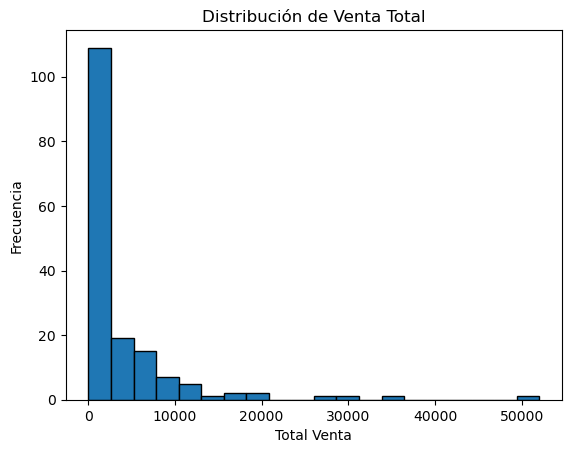

In [ ]:
# Hacemos un histograma de la columna 'total_venta' para visualizar la distribución de las ventas totales:
plt.hist(ventas_trimestre['total_venta'], bins=20, edgecolor='black')
plt.title('Distribución de Venta Total')
plt.xlabel('Total Venta')
plt.ylabel('Frecuencia')
plt.show()  

Vemos que el ticket promedio es de $3614.71. Sin embargo, la mediana es de $980, es decir, hay algunos tickets muy altos que hacen que el promedio suba, como lo muestra el histograma donde observamos un sesgo a la derecha de los datos. Hay muchos tickets de menos de $10,000, y pocos tickets con montos extremadamente altos, de hasta $50,000. Este patrón podría indicar la existencia de compras ocasionales de alto valor o clientes que adquieren productos en volumen.

In [99]:
# Encontramos los valores atípicos en la columna 'total_venta' utilizando el método describe() para identificar los cuartiles y el rango intercuartílico (IQR):
Q1 = ventas_trimestre['total_venta'].quantile(0.25)
Q3 = ventas_trimestre['total_venta'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")


limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


print(f"Limite inferior: {limite_inferior}")
print(f"Limite superior: {limite_superior}")


print("Valores atípicos en total_venta:")
print(ventas_trimestre[(ventas_trimestre['total_venta'] < limite_inferior) | (ventas_trimestre['total_venta'] > limite_superior)])

Q1: 440.0
Q3: 3886.25
IQR: 3446.25
Limite inferior: -4729.375
Limite superior: 9055.625
Valores atípicos en total_venta:
            codigo                                       producto  cantidad  \
19    810158836396   Coqui OP 14 The Azure Seas Seven Booster Box         3   
20    810158836396   Coqui OP 14 The Azure Seas Seven Booster Box        24   
31    195166306292                     MTG Lorwyn Eclipsed Bundle        16   
36    195166305325           MTG Lorwyn Eclipsed Play Booster Box        12   
44    195166289762             MTG Marvel Spider-Man Play Booster       127   
72    810155273705      Coqui Riftbound Spiritforged Pre-Rift Kit        15   
106   195166286341  Coqui MTG Edge Of Eternities Play Booster Box         4   
109   195166253602   Coqui MTG Modern Horizons 3 Play Booster Box         2   
111   810158836396   Coqui OP 14 The Azure Seas Seven Booster Box         3   
112   810158833562                   Coqui OP Tin Pack Set Vol. 2        55   
115   8101

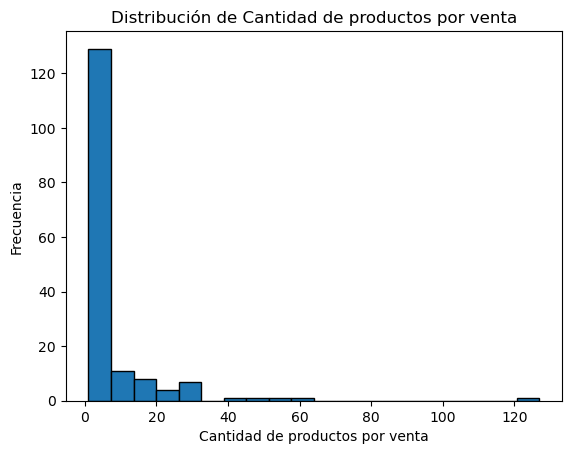

In [100]:
# Hacemos un histograma de la columna 'cantidad' para visualizar la distribución del número de productos por venta:
plt.hist(ventas_trimestre['cantidad'], bins=20, edgecolor='black')
plt.title('Distribución de Cantidad de productos por venta')
plt.xlabel('Cantidad de productos por venta')
plt.ylabel('Frecuencia')
plt.show()

Respecto a la cantidad de productos por ticket, hay una situación similar, pues el promedio es de 6.94 artículos, mientras que la mediana es de 2, lo que confirma la presencia de valores extremos que elevan el promedio.

En el histograma hay un sesgo a la derecha en los datos, pues muestra que la mayoría de las compras contienen pocos artículos, mientras que un número reducido de transacciones incluye grandes volúmenes. 

Es importante mencionar que existen outliers con cantidades significativamente altas (superiores a 100 artículos), que podrían corresponder a clientes clientes mayoristas o compras en volumen.

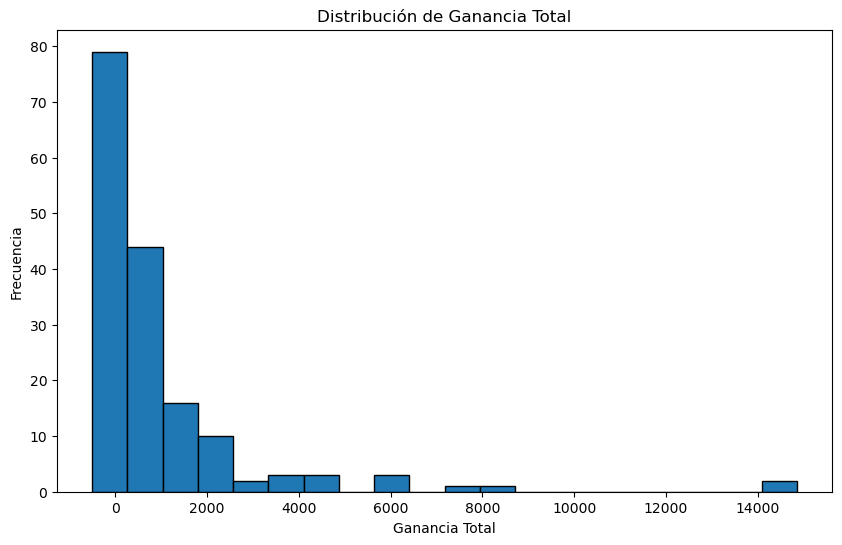

In [101]:
# Hacemos un histograma de la columna 'ganancia_total' para visualizar la distribución de las ganancias totales de las ventas:
plt.figure(figsize=(10, 6))
plt.hist(ventas_trimestre['ganancia_total'], bins=20, edgecolor='black')
plt.title('Distribución de Ganancia Total')
plt.xlabel('Ganancia Total')
plt.ylabel('Frecuencia')
plt.show()